<a href="https://colab.research.google.com/github/Tinugoyal/Exploratory-Data-Analysis/blob/main/experiment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


--- Part A: Loading and Preprocessing MNIST ---
Number of samples: 70000
Number of classes: 10
Image dimensions: 28 x 28 (784 total features)


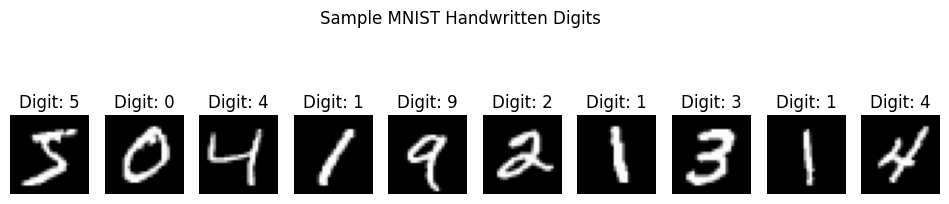

In [ ]:
print("--- Part A: Loading and Preprocessing MNIST ---")

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(int)

num_samples, num_features = X.shape
num_classes = len(np.unique(y))
print(f"Number of samples: {num_samples}")
print(f"Number of classes: {num_classes}")
print(f"Image dimensions: 28 x 28 ({num_features} total features)")


X_norm = X / 255.0


fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i in range(10):
    axes[i].imshow(X_norm[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Digit: {y[i]}")
    axes[i].axis('off')
plt.suptitle("Sample MNIST Handwritten Digits")
plt.show()




--- Part B: Principal Component Analysis ---
Components required to retain 90% variance: 87
Components required to retain 95% variance: 154
Components required to retain 99% variance: 331


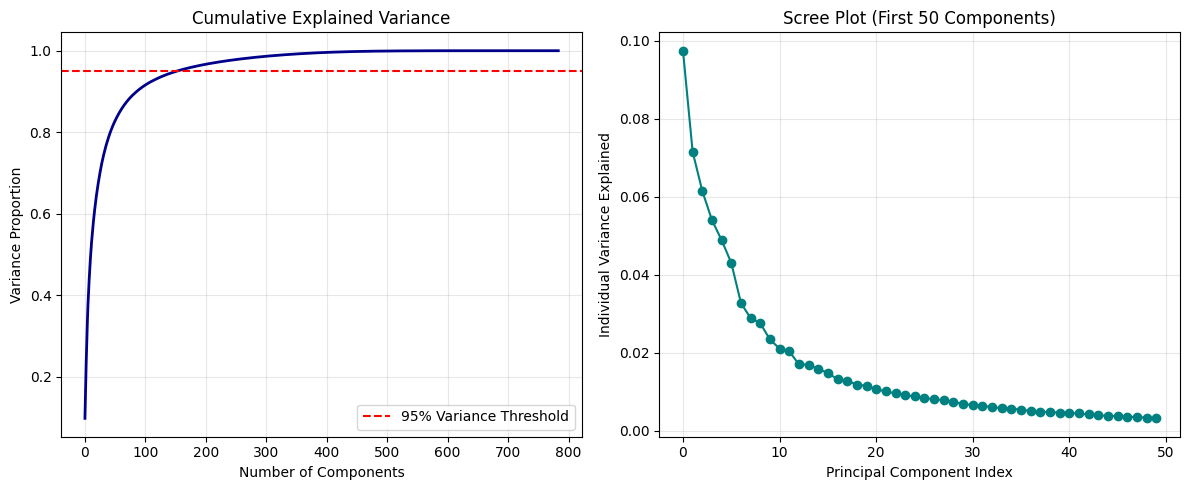

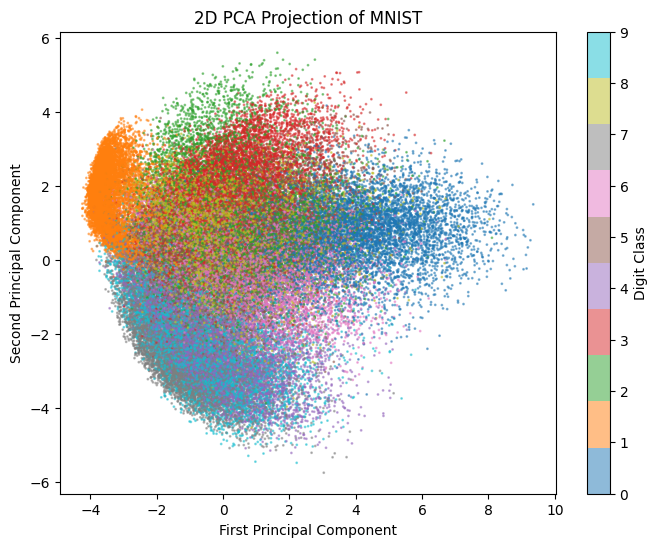

In [ ]:
print("\n--- Part B: Principal Component Analysis ---")
pca_full = PCA().fit(X_norm)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

milestones = [0.90, 0.95, 0.99]
for m in milestones:
    comps = np.argmax(cumulative_variance >= m) + 1
    print(f"Components required to retain {int(m*100)}% variance: {comps}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cumulative_variance, lw=2, color='darkblue')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Proportion')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(pca_full.explained_variance_ratio_[:50], marker='o', color='teal')
plt.title('Scree Plot (First 50 Components)')
plt.xlabel('Principal Component Index')
plt.ylabel('Individual Variance Explained')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pca_2d = PCA(n_components=2).fit_transform(X_norm)
pca_50d = PCA(n_components=50).fit_transform(X_norm)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=y, cmap='tab10', alpha=0.5, s=1)
plt.colorbar(scatter, label='Digit Class')
plt.title('2D PCA Projection of MNIST')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.show()



--- Part C: t-SNE Projections ---
Computing t-SNE on PCA-reduced data (50D)...


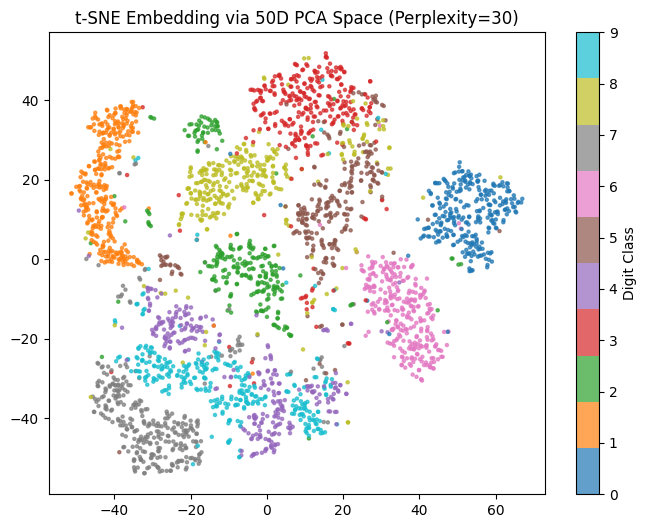

In [ ]:
print("\n--- Part C: t-SNE Projections ---")

subset_indices = np.random.choice(num_samples, 3000, replace=False)
X_subset_norm = X_norm[subset_indices]
X_subset_50d = pca_50d[subset_indices]
y_subset = y[subset_indices]

print("Computing t-SNE on PCA-reduced data (50D)...")
tsne_pca = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_tsne_pca = tsne_pca.fit_transform(X_subset_50d)

plt.figure(figsize=(8, 6))
scatter_tsne = plt.scatter(X_tsne_pca[:, 0], X_tsne_pca[:, 1], c=y_subset, cmap='tab10', alpha=0.7, s=5)
plt.colorbar(scatter_tsne, label='Digit Class')
plt.title('t-SNE Embedding via 50D PCA Space (Perplexity=30)')
plt.show()

In [ ]:
print("\n--- Part D: Training and Benchmarking KNN Classifiers ---")
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X_norm, y, train_size=10000, test_size=2000, random_state=42)
X_train_pca, X_test_pca, _, _ = train_test_split(pca_50d, y, train_size=10000, test_size=2000, random_state=42)

knn_orig = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
t0 = time.time()
knn_orig.fit(X_train_orig, y_train)
t_train_orig = time.time() - t0

t0 = time.time()
preds_orig = knn_orig.predict(X_test_orig)
t_pred_orig = time.time() - t0
acc_orig = accuracy_score(y_test, preds_orig)

knn_pca = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
t0 = time.time()
knn_pca.fit(X_train_pca, y_train)
t_train_pca = time.time() - t0

t0 = time.time()
preds_pca = knn_pca.predict(X_test_pca)
t_pred_pca = time.time() - t0
acc_pca = accuracy_score(y_test, preds_pca)

print(f"\n{'Metric':<25} | {'Original (784D)':<18} | {'PCA Reduced (50D)':<18}")
print("-" * 68)
print(f"{'Accuracy':<25} | {acc_orig*100:.2f}%{'':<12} | {acc_pca*100:.2f}%")
print(f"{'Training Time (s)':<25} | {t_train_orig:.4f}s{'':<11} | {t_train_pca:.4f}s")
print(f"{'Prediction Time (s)':<25} | {t_pred_orig:.4f}s{'':<11} | {t_pred_pca:.4f}s")




--- Part D: Training and Benchmarking KNN Classifiers ---

Metric                    | Original (784D)    | PCA Reduced (50D) 
--------------------------------------------------------------------
Accuracy                  | 94.75%             | 95.50%
Training Time (s)         | 0.0261s            | 0.0047s
Prediction Time (s)       | 6.2437s            | 0.4687s
